# 02 - Instance Segmentation

Ejemplos para modelos `*-seg.pt`: lectura de poligonos, filtrado y ploteo directo de mascaras.


In [2]:
from vision.yolo.infer import predict_image
from vision.yolo.plotting import (
    plot_segmentation_masks,
    plot_image_detections,
    plot_class_distribution,
)

MODEL = "yolo11s-seg.pt"
IMAGE = "input/elevate-nYgy58eb9aw-unsplash.jpg"


In [4]:
df = predict_image(MODEL, IMAGE, confidence=0.25, task="segment", imgsz=320)
print(
    df.columns.tolist()
)

display(df.head())


['frame', 'track_id', 'class_id', 'class_name', 'confidence', 'xmin', 'ymin', 'xmax', 'ymax', 'polygon', 'mask', 'keypoints', 'timestamp']


,frame,track_id,class_id,class_name,confidence,xmin,ymin,xmax,ymax,polygon,mask,keypoints,timestamp
0,0,None,0,person,0.915119,2.602997,431.398224,751.750793,2137.647217,"[[341.54998779296875, 417.45001220703125], [34...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",None,None
1,0,None,0,person,0.911817,795.631348,696.724670,1521.485352,2146.518066,"[[1451.5875244140625, 1252.3499755859375], [14...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",None,None
2,0,None,0,person,0.899567,1599.473267,455.335815,2414.387207,2143.627197,"[[1831.0875244140625, 455.3999938964844], [183...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",None,None
3,0,None,0,person,0.858338,2059.984131,315.862122,3033.236816,2147.421875,"[[2618.550048828125, 303.6000061035156], [2618...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",None,None
4,0,None,41,cup,0.252620,1609.412476,1161.113525,1752.800293,1420.250610,"[[1612.875, 1176.449951171875], [1612.875, 143...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",None,None


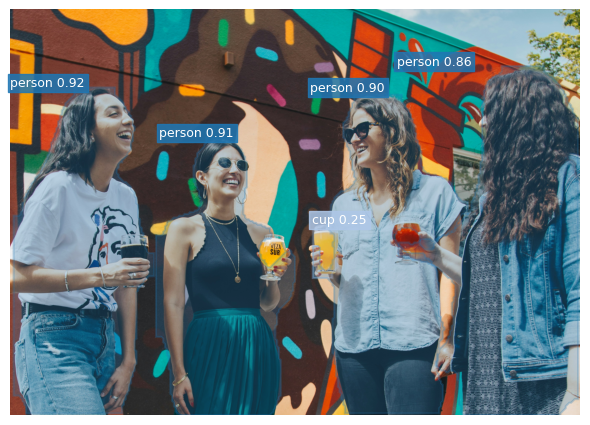

In [7]:
# Plot directo de mascaras + cajas
plot_segmentation_masks(
    IMAGE,
    df,
    draw_boxes=False,
    confidence_threshold=0.25,
    figsize=(6, 5)
)


In [8]:
# Inspeccion de vertices por deteccion
with_polygons = df[df["polygon"].notna()].copy()
with_polygons["n_vertices"] = with_polygons["polygon"].apply(
    lambda p: len(p) if isinstance(p, list) else 0
)
print(with_polygons[["class_name", "confidence", "n_vertices"]].head())


  class_name  confidence  n_vertices
0     person    0.915119         137
1     person    0.911817         147
2     person    0.899567         200
3     person    0.858338         134
4        cup    0.252620           8


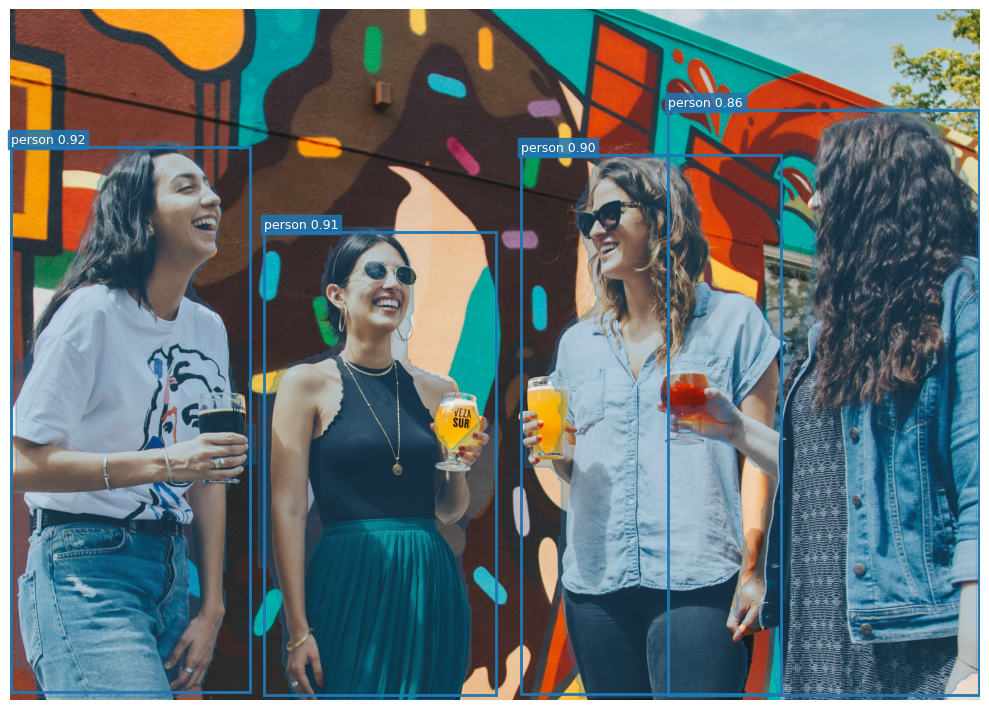

In [9]:
# Filtrar una clase o una confianza antes del plot
filtered = df[df["confidence"].ge(0.45)]
plot_image_detections(
    IMAGE,
    filtered,
    draw_boxes=True,
    draw_polygons=True,
    draw_keypoints=False,
)


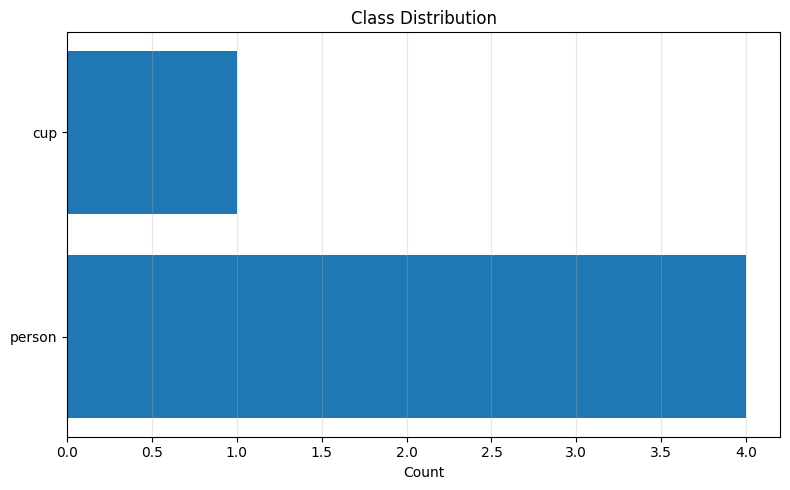

In [10]:
plot_class_distribution(df)


,frame,track_id,class_id,class_name,confidence,xmin,ymin,xmax,ymax,polygon,mask,keypoints,timestamp
0,0,None,0,person,0.915119,2.602997,431.398224,751.750793,2137.647217,"[[341.54998779296875, 417.45001220703125], [34...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",None,None
1,0,None,0,person,0.911817,795.631348,696.724670,1521.485352,2146.518066,"[[1451.5875244140625, 1252.3499755859375], [14...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",None,None
2,0,None,0,person,0.899567,1599.473267,455.335815,2414.387207,2143.627197,"[[1831.0875244140625, 455.3999938964844], [183...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",None,None
3,0,None,0,person,0.858338,2059.984131,315.862122,3033.236816,2147.421875,"[[2618.550048828125, 303.6000061035156], [2618...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",None,None


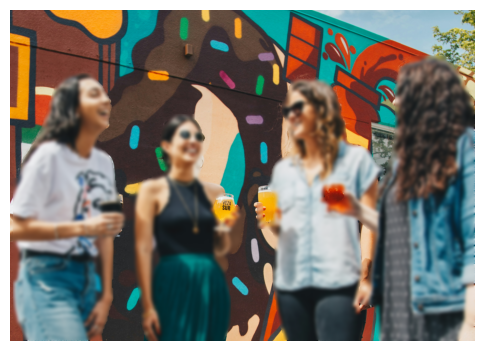

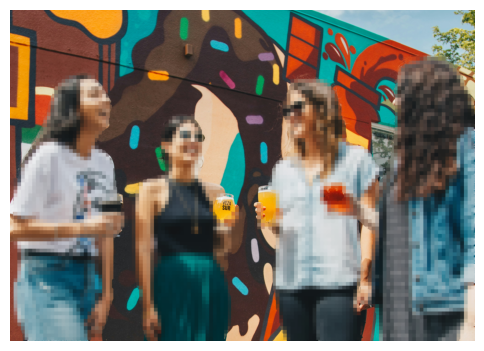

In [11]:
from PIL import Image, ImageFilter, ImageDraw
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# create a df only for "people"
people = df[df["class_name"] == "person"].copy()

display(people.head())

img = Image.open(IMAGE).convert("RGB")


def polygon_points(poly):
    if poly is None:
        return None
    arr = np.asarray(poly)
    if arr.size == 0:
        return None
    if arr.ndim == 1:
        arr = arr.reshape(-1, 2)
    return [(int(round(x)), int(round(y))) for x, y in arr[:, :2]]


def make_polygon_mask(size, points):
    mask = Image.new("L", size, 0)
    draw = ImageDraw.Draw(mask)
    draw.polygon(points, fill=255)
    return mask


# --- blurred mask ---
img_blur = img.copy()
blurred_full = img.filter(ImageFilter.GaussianBlur(radius=10))

for _, row in people.iterrows():
    points = polygon_points(row["polygon"])
    if not points:
        continue
    mask = make_polygon_mask(img.size, points)
    img_blur = Image.composite(blurred_full, img_blur, mask)

plt.figure(figsize=(6, 5))
plt.imshow(img_blur)
plt.axis("off")
plt.show()


# --- pixelated mask ---
img_pixel = img.copy()
small_w, small_h = max(1, img.width // 24), max(1, img.height // 24)
pixelated_full = img.resize((small_w, small_h), resample=Image.BILINEAR).resize(
    img.size, resample=Image.NEAREST
)

for _, row in people.iterrows():
    points = polygon_points(row["polygon"])
    if not points:
        continue
    mask = make_polygon_mask(img.size, points)
    img_pixel = Image.composite(pixelated_full, img_pixel, mask)

plt.figure(figsize=(6, 5))
plt.imshow(img_pixel)
plt.axis("off")
plt.show()
